<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/AI/3D_%EB%A0%8C%EB%8D%94%EB%A7%81_%ED%95%B5%EC%8B%AC%EC%9D%B4%EB%A1%A0_%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3D 공간내의 객체 (object)_기본 단위 : 삼각형

In [6]:
# 삼각형의 법선 벡터 (Normal)
import numpy as np

# 삼각형의 세 꼭지점 (x,y,z)
# z : 깊이 (원근 표시 가능, z가 작으면 가까움, 크면 멈)
# v : vertex (점)
# 점 >> 선(edge) >> 면(face) : triangle(삼각형)
v0 = np.array([0,0,0])
v1 = np.array([1,0,0])
v2 = np.array([0,1,0])

# 두 변 벡터
edge1 = v1 - v0
edge2 = v2 - v0
# edge2

# 외적 (cross product) 활용, 법선 벡터 계산
normal = np.cross(edge1, edge2)  # array([0, 0, 1])
print('normal vector(법선 벡터) :',normal)   # z축 방향

normal vector(법선 벡터) : [0 0 1]


메쉬의 3요소 (VEF)
- V (Vertex) : 점 (공간상의 점) >> x, y, z
- E (Edge) : 선 (두 점을 이은 선)
- F (Face) : 면 (엣지, 즉 선들이 닫혀서 만들어진 삼각형 면)

In [7]:
verticies = [
    [0.0, 0.0, 0.0],    # vertex0
    [1.0, 0.0, 0.0],    # vertex1
    [0.5, 1.0, 0.0],    # vertex2
]

# face : 어떤 vertex 연결하는가
faces = [[0, 1, 2]]
# 0번, 1번, 2번 vertex로 이루어진 '삼각형

NeRF (Nerual Radiance Fields) 신경 방사 필드
- 여러 장 사진 활용해서 3D공간이 어떨까 추측해, 찍지 않은 아무 각도에서나 이미지를 생성하는 AI

- 입력 : 공간 좌표(x,y,z), 카메라(시선) 보는 방향(방위각, 고도각) >> 5 입력
- 출력 : 색상정보(rgb), 부피 밀도(sigma)

볼룸 렌더링
- 미분 가능 >> 역전파 >> 딥러닝
- 색상기여도 : 티알씨 (T:투명도, alpha:불투명, color(색상))
- T (투명도) : 누적 투과도 (tranmittance) 이 지점(i)까지 빛이 막히지 않고 올 확률
- alpha (불투명도) 부피 밀도(해당 점(i)에 물질이 있을 확률)와 샘플 간격(광선을 따라 측정하는 간격)
- color (해당 점(i) 색상) : i번째 샘플의 rgb

In [ ]:
import numpy as np

def volume_rendering(sigma, color, delta):
    # 각 샘플의 불투명도 alpha
    # 특정 샘플 구간(delta)에 광선이 물질에 부딪혀 차단되는 확률
    # 밀도 (sigma) 높거나, 간격 (delta) 넓으면 alpha는 1에 가까워짐
    # 밀도가 0 >> alpha = 0 (완전 투명)
    alpha = 1.0 - np.exp(-sigma * delta)

    # 누적 투과도 T
    T = np.cumprod(np.concatenate(([1.0], 1.0 - alpha[:-1])))
    # [1.0] 첫번째 샘플까지는 가로막는게 없음, 맨 앞에 1 붙여줌
    # alpha[:-1] i번째 지점 투과도는 i-1번째 불투명도 (가리는 물체)에 영향을 받으니까 마지막 원소 제외
    # cumprod 누적곱 (이전 지점 투과도를 모두 곱함) >> 현재 지점까지 빛이 도달할 확률 구하기

    # 가중치 계산
    # 해당 샘플지점(i)이 최종 색상에 얼마나 기여하는지 나타냄(기여도)
    # 직관적으로 생각, 아무리 색이 진해도(alpha 크다) 앞에 물체(장애물)가 빛을 다 막으면
    # >> T가 0에 가까우면 >> weight 낮아짐
    weights = T * alpha

    # 최종 픽셀 컬러(색상기여도) : 가중 합산
    # 각 샘플의 색상(ci)에 계산된 가중치 곱한 뒤 더하기
    C = np.sum(weights[:,None] * color, axis = 0)
    # weights는 (n, ) 1차원 배열 (각 샘플 지점의 가중치가 n개)
    # weights[:,None] (n, )형태의 가중치를 (n,1)로 확장
    # weights[:,None] None이 의미하는 바 (n,1) 2차원 배열 (np.newaxis와 동일한 역할)
    # >> 기존 배열에 (배열의 자리(행 또는 열)) 차원을 늘려줌
    # color는 (n,3) 3은 rgb
    # 차원이 안 맞음 weight*color 해야는데 weight는 (n,1), color는 (n,3)임
    # >> 브로드캐스팅 해서 차원을 맞춰줌

    return C




# sigma : 부피 밀도 [n]
# color : 색상 (n, 3) 3 : rgb
# deftal : 샘플간격 배열 (n)

In [11]:
# C =  np.sum(weights[:,None] * color, axis =0) 예시
# 샘플 2개 있다고 가정

import numpy as np

# weights (2,) 2개 샘플 가중치
weights = np.array([0.5, 0.2])

# color (2, 3) 2개 샘플 지점 색상 (빨, 초)
color = np.array([
    [255,0,0],
    [0,255,0]
])

print(weights.shape)    # (2,)
print(color.shape)  # (2, 3)

# weights[:,None] 적용 >> 차원 확장
# (2,) >> (2, 1)
weights_extended = weights[:,None]
print(weights_extended.shape)   # (2, 1)

final_pixel_color = np.sum(weights[:,None] * color, axis =0)
print(final_pixel_color)
print(final_pixel_color.shape)  # (3,)

(2,)
(2, 3)
(2, 1)
[127.5  51.    0. ]
(3,)


PE (Positional Encoding)

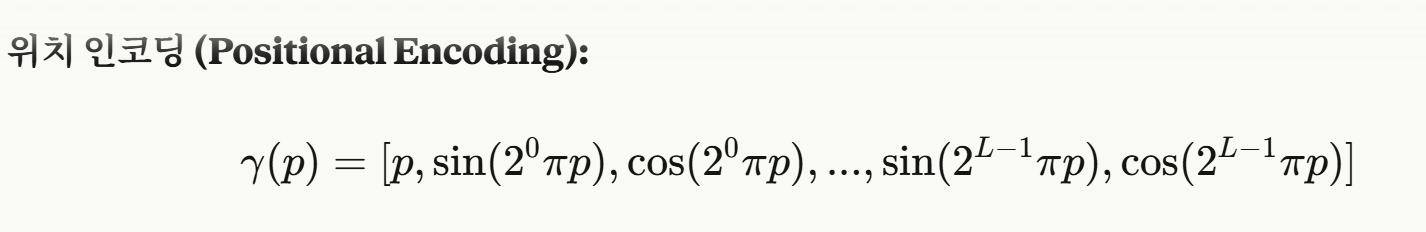

In [15]:
import torch

def position_encoding(p, L=10):
    encodings = [p]
    for freq in range(L):
        for fn in [torch.sin, torch.cos]:
            encodings.append(fn(2.0 ** freq * torch.pi * p))
    return torch.cat(encodings, dim=-1)


# p : position (입력 좌표 : x,y,z 적용)
# L : 인코딩 지수 (default = 10)

In [18]:
x = torch.tensor([[0.5,0.3,0.8]])
pe = position_encoding(x, L=10)

print(x.shape)  # 원본 [1,3]
print(pe.shape) # 사인/코사인 변환 [1,63] 3(원본) + 3(각 좌표 축당) * 2(sin,cos) * 10(주파수 단계)

# 3차원 (s,y,z) 낮은 주파수 >> 고주파(날카로운 모서리, 엣지, 질감) 변경 63차원
# positional encoding 을 NeRF에 사용하는 이유
# >> 좌표의 해상도 높이기 위해 (저주파:3차원 >> 고주파:63차원) 원래 좌표(x,y,z) [1,3]뒤에 이어 붙임 (concat)

torch.Size([1, 3])
torch.Size([1, 63])


좌표계
- 월드 좌표계 (0,0,0) 절대 기준점
  - 카메라가 움직여도 (x,y,z) 절대 변하지 않음

- 로컬 좌표계
  - 물체(자동차 등) 자체의 중심이 (0,0,0) 좌표

- 카메라 좌표계 (view space)
  - 방위각(좌우이동), 고도각(상하 이동) 이용, 카메라가 바라보는 방향 결정
  - 월드좌표계의 점이 있다면, 카메라를 원점으로 하는 좌표계로 변환함(view matrix 적용)

좌표 변환
- 카메라가 월드 좌표계 (0,0,0)에 있을 때
  - x = d * cos(고도각) * sin(방위각)
  - 카메라 좌표 = 월드 좌표
- 카메라가 이동(xc,yc,zc) 했을 때
  - x_world = xc + d * cos(고도각) * sin(방위각)
  - 카메라 기준의 상대적 위치를 월드 좌표로 보정

- 방위각, 고도각이 있으므로 구면 좌표계임
- 구면 좌표계의 d의미
  - 카메라(원점)로부터 그 점(물체)까지의 직선 거리
- 방위각 : 좌우 회전 각도
- 고도각 : 상하 회전 각도

결론적으로 방위각, 고도각, 거리(d) 있으니깐 카메라 기준임

여기에 월드 위치를 더해서 최종 월드 좌표 매핑

볼륨 렌더링과 무슨 상관?
-  광선(ray) 카메라 위치, 각도(방위각,고도각) >> 광선 방향 결정
- 샘플링(d) 광선(ray)따라서 카메라로부터 거리 d를 조금씩 늘려서 지점을 찍음
- 좌표 생성 : 각 d점마다 월드 좌표 (x,y,z) 계산
- 인코딩 : 이 (x,y,z)를 PE(Positional Encoding) 활용 3차원을 63차원으로 확장 (고주파 정밀하게)
- 적분 : 확장된 데이터를 신경망에 넣음 >> 부피 밀도(sigma), 색상(color) >> volume rendering 수식에 합쳐
- 궁극적으로 최종 픽셀 색상을 만들어


광선 방정식 (ray origin / ray direction)

r(t) = o + t*d
- o : ray origin (카메라 위치)
- d : ray direction (단위 방향 벡터)
- t : 거리 파라미터 (t > 0)

즉 r(t)란, 레이저 포인터 쓸 때 특정 거리 t에 있는 점

카메라 파라미터
- 내부
  - 렌즈의 특성 (초점 거리_픽셀단위, 주점_이미지 중심)
- 외부
  - 이동 벡터(t), 회전 행렬(R, 3*3)

In [20]:
import numpy as np

# 각 픽셀에 대응하는 ray origin 과 ray direction 게산
def get_rays(H, W, focal, pose):
    # 픽셀 격자 생성
    i, j = np.meshgrid(
        np.arange(W, dtype=np.float32),
        np.arange(H, dtype=np.float32),
        indexing='xy'
        )
    # i : 모든 픽셀의 가로 위치(x)
    # j : 모든 픽셀의 세로 위치(y)
    # >> H*W 크기 행렬

    # pixel >> 카메라 좌표계 방향 벡터
    dirs = np.stack([
        (i - W * 0.5) / focal,          # x: 가로 방향 각도 조절
         - (j - H * 0.5) / focal,       # y: 세로 방향 각도 조절 (이미지 j축 반전 보정)
         - np.ones_like(i)],            # z : 정면 방향 (-1로 고정)
                    axis=-1
    )
    # 이미지 중심을 (0,0)에 맞추고, 초점거리(focal)로 나누어줌
    # (i - W * 0.5)
    # >> 즉 , 이미지 중심으로부터 물체의 픽셀이 얼마나 떨어져 있는가? (물리적 거리, 픽셀단위)
    # /focal (눈, 카메라 원점)에서 이미지 평면까지 거리 나누어줌
    # 픽셀 단위 거리 >> 각도 단위의 기울기 (기울기 벡터)로 변환하기 위해서
    #  - (j - H * 0.5) /  focal
    # 이미지 좌표계는 j축(y축)이 숫자가 커질수록 아래로 내려가는 반면에,
    # 우리 눈(카메라)는 y축이 커지면 위로 올라감 >> 반전 보정함
    # >> 실제 각도에 해당하는 방향 벡터 구하기
    # - np.ones_like(i) 쓰는 이유
    # >> - np.ones_like(i) 행렬 크기(shape) 맞추기 위함
    # >> i, j는 모든 픽셀 정보를 담고있는 H*W 크기 행렬
    # >> 모든 픽셀에 대해 똑같이 '정면은 -Z방향' 정보 추가를 위해 i와 똑같은 크기 행렬 만들고
    # 모두 -1로 채움, -1로 채우는 이유 >> 카메라 정면 (내 눈에서 멀어지는 방향)이 -z방향이여
    # >> 고로, 정면방향벡터를 '-1'로 고정함

    # 카메라 좌표계에서 월드 좌표계로 변환
    ray_d = np.sum(dirs[...,None, :] * pose[:3,:3], axis=-1)
    # dirs[...,None, :] 앞에서 구한 카메라 기준 방향 벡터 (H,W,1,3)
    # (H,W,1,3) height, weight, newaxis(새로 추가된 차원 None), 각 픽셀이 가진 방향 벡터(x,y,z)
    # psoe[:3, :3] (3*3) 행렬 만남 >> (1,3)@(3,3) = (1,3) 월드 방향 벡터
    # >> 이미지의 모든 픽셀 (H*W)에 대해 한번에 수행
    # axis=-1 기준, sum (행렬 곱셈들의 결과를 모두 합) >> (H,W,3)

    # ray origin (카메라 위치) pose 이동 벡터
    ray_o = np.broadcast(pose[:3, -1], ray_d.shape)
    # pose[:3, -1] (원본)카메라의 월드좌표 (값 : xc,yc,zc) shape : (3, ) 단 3개의 수
    # ray_d 이미지 전체 방향 벡터 (H,W,3)
    # >> 만약 H:800, W:600 이미지면 >> (800,600,3) = 1440000
    # 이 연산 수행 결과 모든 픽셀의 ray_o는 [xc,yc,zc]가 됨
    return ray_o, ray_d

# H, W : 이미지 높이, 너비
# focla : 초점 거리
# pose : 카메라 자세 행렬 [4*4]